# C3 — GNN-LSTM + Stacking — **Perfect Weather + HYSPLIT Forecast**

## Executive Summary
Identical to `B3_gnn_lstm_stacking_perfect_forecast.ipynb` **except** HYSPLIT
features are also shifted to t+h (alongside MET_COLS) everywhere features are built.

**Weather mode:** `"perfect_forecast_full"` — GNN node met features (TEMP,
WIND_SPEED, blh, HUMIDITY) AND HYSPLIT numeric/categorical columns are all
shifted to t+24. Stacking base models and meta-learner receive the same.

**Series comparison:**
- A3: weather at t, HYSPLIT at t
- B3: weather at t+24, HYSPLIT at t
- C3: weather at t+24, HYSPLIT at t+24 ← this notebook

The final cell merges A + B + C series into a single `comparison_table_all.csv`.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

from src.config import (
    DATA_PATH, TARGET, HORIZONS, MODEL_DIR, FIGURES_DIR, RESULTS_DIR, RANDOM_SEED
)
from src.data_loader import load_data, train_test_split
from src.feature_engineering import build_feature_matrix, WEATHER_MODE_PERFECT_FULL
from src.models.gnn_stacking import (
    build_adjacency_matrix, build_gnn_sequence_dataset,
    train_gnn_lstm, predict_gnn_lstm,
    train_stacking_ensemble, predict_stacking,
    ALL_STATIONS_ORDERED
)
from src.evaluation import (
    compute_metrics, plot_horizon_metrics, plot_actual_vs_predicted,
    plot_smog_episodes, comparison_table
)
from src.utils import ensure_dirs, set_seed

WEATHER_MODE = WEATHER_MODE_PERFECT_FULL   # ← only difference from B3

set_seed(42)
ensure_dirs(MODEL_DIR, FIGURES_DIR, RESULTS_DIR)
sns.set_theme(style='whitegrid', palette='tab10')
print(f'Weather mode: {WEATHER_MODE}')

Weather mode: perfect_forecast_full


## 1. Load Data

In [2]:
df = load_data(DATA_PATH)
train_df, test_df = train_test_split(df)
print(f'Train: {len(train_df):,} | Test: {len(test_df):,}')

15:20:36 | src.data_loader | INFO | Loading data from D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\data\raw\FINAL_merged_PM25_1g_all_seasons.csv
15:20:37 | src.data_loader | INFO | Missing values per column:
MzOtwoBrzozo    1084
MzWarWokalna    2028
MzWarAlNiepo     575
MzLegZegrzyn    1511
MzPiasPulask    1002
MzWarChrosci     416
MzWarBajkowa     636
dir_48            48
dir_24            48
15:20:37 | src.data_loader | INFO | Loaded 52608 rows, 27 columns, range 2019-01-01 00:00:00 → 2024-12-31 23:00:00
15:20:37 | src.data_loader | INFO | Train: 43824 rows (2019-01-01 00:00:00 → 2023-12-31 23:00:00)
15:20:37 | src.data_loader | INFO | Test : 8784 rows (2024-01-01 00:00:00 → 2024-12-31 23:00:00)


Train: 43,824 | Test: 8,784


## 2. Graph Construction

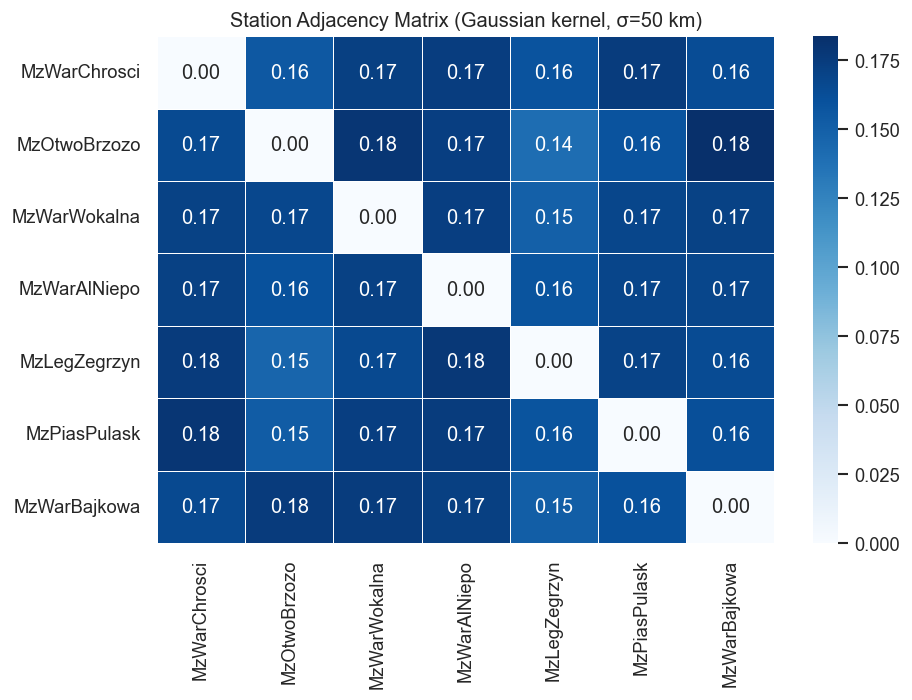

In [3]:
A_static = build_adjacency_matrix(sigma_km=50)
adj_df = pd.DataFrame(A_static, index=ALL_STATIONS_ORDERED, columns=ALL_STATIONS_ORDERED)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(adj_df, annot=True, fmt='.2f', cmap='Blues', ax=ax, linewidths=0.5)
ax.set_title('Station Adjacency Matrix (Gaussian kernel, σ=50 km)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'C3_adjacency.png', bbox_inches='tight')
plt.show()

## 3. Build GNN Sequence Datasets
Met node features AND HYSPLIT shifted to t+24 via `weather_mode`.

In [4]:
SEQ_LEN_GNN = 24

X_gnn_train, y_gnn_train, A_static = build_gnn_sequence_dataset(
    train_df, seq_len=SEQ_LEN_GNN, horizons=HORIZONS, weather_mode=WEATHER_MODE
)
X_gnn_test, y_gnn_test, _ = build_gnn_sequence_dataset(
    test_df, seq_len=SEQ_LEN_GNN, horizons=HORIZONS, weather_mode=WEATHER_MODE
)

print(f'GNN Train: X={X_gnn_train.shape}, y={y_gnn_train.shape}')
print(f'GNN Test : X={X_gnn_test.shape}, y={y_gnn_test.shape}')

15:20:38 | src.feature_engineering | INFO | perfect_forecast_full: shifted 8 MET + 10 HYSPLIT_NUM + 2 HYSPLIT_CAT by -24 h
15:20:38 | src.models.gnn_stacking | INFO | build_gnn_sequence_dataset | seq_len=24 | weather_mode=perfect_forecast_full
15:20:38 | src.models.gnn_stacking | INFO | GNN sequences: X=(36467, 24, 7, 10) y=(36467, 24)
15:20:38 | src.feature_engineering | INFO | perfect_forecast_full: shifted 8 MET + 10 HYSPLIT_NUM + 2 HYSPLIT_CAT by -24 h
15:20:38 | src.models.gnn_stacking | INFO | build_gnn_sequence_dataset | seq_len=24 | weather_mode=perfect_forecast_full
15:20:38 | src.models.gnn_stacking | INFO | GNN sequences: X=(7495, 24, 7, 10) y=(7495, 24)


GNN Train: X=(36467, 24, 7, 10), y=(36467, 24)
GNN Test : X=(7495, 24, 7, 10), y=(7495, 24)


## 4. Train GNN-LSTM

In [5]:
val_size = int(0.1 * len(X_gnn_train))
X_gnn_tr  = X_gnn_train[:-val_size]
y_gnn_tr  = y_gnn_train[:-val_size]
X_gnn_val = X_gnn_train[-val_size:]
y_gnn_val = y_gnn_train[-val_size:]

gnn_model, gnn_history = train_gnn_lstm(
    X_gnn_tr, y_gnn_tr, X_gnn_val, y_gnn_val, A_static,
    epochs=80, batch_size=64, patience=15, lr=1e-3,
    save_path=MODEL_DIR / 'gnn_lstm_model_pfx_full.pt'
)
print('GNN-LSTM training complete.')

15:20:38 | src.models.gnn_stacking | INFO | Training GNN-LSTM on cpu
15:20:40 | src.models.gnn_stacking | INFO | GNN-LSTM | seq_len=24  n_nodes=7  n_node_features=10  n_horizons=24  device=cpu
15:20:40 | src.models.gnn_stacking | INFO | Params: epochs=80  batch=64  patience=15  lr=0.00100
15:20:40 | src.models.gnn_stacking | INFO | Training samples=32821  val samples=3646
15:20:40 | src.models.gnn_stacking | INFO | -----------------------------------------------------------------
15:21:26 | src.models.gnn_stacking | INFO | Epoch   1/80  train=0.18613  val=0.06426  best=0.06426  lr=1.00e-03 *
15:22:15 | src.models.gnn_stacking | INFO | Epoch   2/80  train=0.08435  val=0.08319  best=0.06426  lr=1.00e-03  (no improve 1/15)
15:22:55 | src.models.gnn_stacking | INFO | Epoch   3/80  train=0.07620  val=0.06884  best=0.06426  lr=1.00e-03  (no improve 2/15)
15:23:35 | src.models.gnn_stacking | INFO | Epoch   4/80  train=0.07139  val=0.06798  best=0.06426  lr=1.00e-03  (no improve 3/15)
15:24:18

GNN-LSTM training complete.


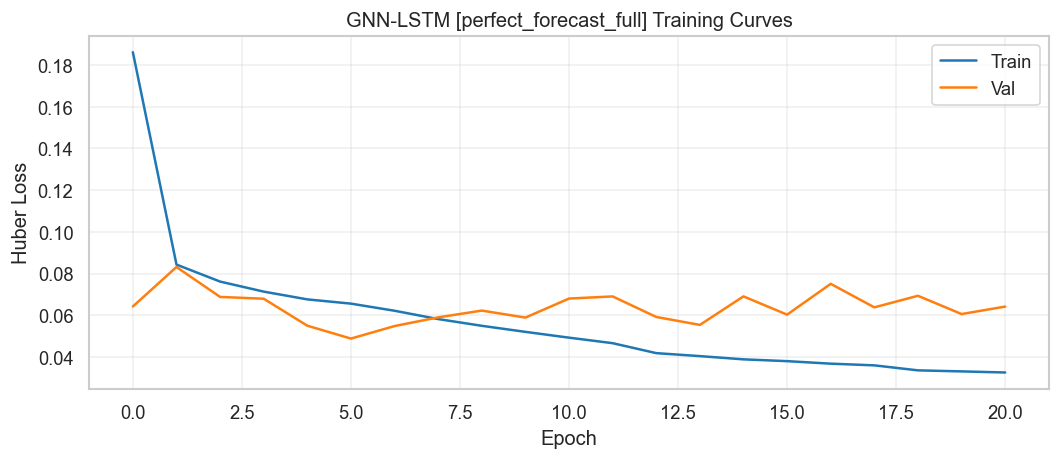

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(gnn_history['train_loss'], label='Train')
ax.plot(gnn_history['val_loss'], label='Val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Huber Loss')
ax.set_title('GNN-LSTM [perfect_forecast_full] Training Curves')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'C3_gnn_loss.png', bbox_inches='tight')
plt.show()

## 5. GNN-LSTM Test Evaluation

In [7]:
gnn_preds = predict_gnn_lstm(gnn_model, X_gnn_test, A_static)
y_gnn_test_true = np.expm1(y_gnn_test)

results_gnn_full = {}
for h_idx, h in enumerate(HORIZONS):
    results_gnn_full[h] = compute_metrics(y_gnn_test_true[:, h_idx], gnn_preds[:, h_idx])

print('GNN-LSTM [perfect_forecast_full] Results:')
for h in [1, 6, 12, 24]:
    m = results_gnn_full[h]
    print(f'  h={h:2d}: MAE={m["MAE"]:.3f}  RMSE={m["RMSE"]:.3f}  R²={m["R2"]:.3f}')

GNN-LSTM [perfect_forecast_full] Results:
  h= 1: MAE=2.681  RMSE=3.763  R²=0.800
  h= 6: MAE=3.740  RMSE=5.272  R²=0.603
  h=12: MAE=4.349  RMSE=6.303  R²=0.436
  h=24: MAE=3.863  RMSE=5.613  R²=0.559


## 6. Stacking Ensemble
All base models use `weather_mode="perfect_forecast_full"` for training and inference.

In [8]:
import joblib
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.compose import TransformedTargetRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
from catboost import CatBoostRegressor

base_model_classes = {
    'xgb': lambda: TransformedTargetRegressor(
        regressor=XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                               random_state=RANDOM_SEED, verbosity=0, tree_method='hist'),
        func=np.log1p, inverse_func=np.expm1),
    'hgb': lambda: TransformedTargetRegressor(
        regressor=HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05,
                                                max_depth=4, random_state=RANDOM_SEED),
        func=np.log1p, inverse_func=np.expm1),
    'lgb': lambda: TransformedTargetRegressor(
        regressor=lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05,
                                     max_depth=4, random_state=RANDOM_SEED, verbose=-1),
        func=np.log1p, inverse_func=np.expm1),
    'cat': lambda: CatBoostRegressor(iterations=300, learning_rate=0.05, depth=4,
                                     random_seed=RANDOM_SEED, verbose=0, loss_function='MAE'),
}

gnn_train_preds = predict_gnn_lstm(gnn_model, X_gnn_train, A_static)

stack_models = {}
stack_oof = {}

for h in tqdm(HORIZONS, desc='Training stacking ensemble [perfect_forecast_full]'):
    X_h, y_h = build_feature_matrix(train_df, horizon=h, weather_mode=WEATHER_MODE)
    h_idx = h - 1

    n_gnn = len(gnn_train_preds)
    n_tab = len(X_h)
    if n_gnn <= n_tab:
        gnn_oof_h = np.full(n_tab, np.nan)
        gnn_oof_h[-n_gnn:] = gnn_train_preds[:, h_idx]
        valid = ~np.isnan(gnn_oof_h)
        X_h_valid = X_h[valid]
        y_h_valid = y_h[valid]
        gnn_oof_h_valid = gnn_oof_h[valid]
    else:
        gnn_oof_h_valid = gnn_train_preds[-n_tab:, h_idx]
        X_h_valid = X_h
        y_h_valid = y_h

    meta, oof_mat = train_stacking_ensemble(
        X_h_valid, y_h_valid,
        gnn_oof_preds=gnn_oof_h_valid,
        save_path=MODEL_DIR / f'meta_learner_pfx_full_h{h}.pkl'
    )
    stack_models[h] = meta
    stack_oof[h] = oof_mat

print('Stacking training complete.')

Training stacking ensemble [perfect_forecast_full]:   0%|          | 0/24 [00:00<?, ?it/s]

15:37:27 | src.feature_engineering | INFO | build_feature_matrix | horizon=1 | weather_mode=perfect_forecast_full
15:37:28 | src.feature_engineering | INFO | perfect_forecast_full: shifted 8 MET + 10 HYSPLIT_NUM + 2 HYSPLIT_CAT by -1 h
15:37:28 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
15:37:28 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
15:37:28 | src.feature_engineering | INFO |   X: (38271, 45) | y mean=17.38, y std=12.69
15:37:28 | src.models.gnn_stacking | INFO | OOF [1/4]: fitting base model 'xgb' across 5 folds
15:37:28 | src.models.gnn_stacking | INFO |   fold 1/5 — train=6082 val=6077
15:37:29 | src.models.gnn_stacking | INFO |   fold 2/5 — train=12159 val=6077
15:37:30 | src.models.gnn_stacking | INFO |   fold 3/5 — train=18236 val=6077
15:37:31 | src.models.gnn_stacking | INFO |   fold 4/5 — train=24313 val=6077
15:37:33 | src.models.gnn_stacking | INFO |   fold 5/5 — train=30390 v

Stacking training complete.


## 7. Stacking Evaluation on Test Set

In [9]:
meta_feature_cols = [c for c in
                     ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'blh', 'pm25_now']
                     if c in build_feature_matrix(test_df, horizon=1,
                                                  weather_mode=WEATHER_MODE)[0].columns]

results_stack_full = {}

for h in tqdm(HORIZONS, desc='Evaluating stacking [perfect_forecast_full] on test'):
    X_tr_h, y_tr_h = build_feature_matrix(train_df, horizon=h, weather_mode=WEATHER_MODE)
    X_te_h, y_te_h = build_feature_matrix(test_df,  horizon=h, weather_mode=WEATHER_MODE)

    base_preds_test = []
    for name, factory in base_model_classes.items():
        m = factory()
        m.fit(X_tr_h.values, y_tr_h.values)
        base_preds_test.append(m.predict(X_te_h.values))

    h_idx = h - 1
    n_gnn_test = len(gnn_preds)
    n_tab_test = len(X_te_h)
    gnn_test_h = np.zeros(n_tab_test)
    if n_gnn_test >= n_tab_test:
        gnn_test_h = gnn_preds[-n_tab_test:, h_idx]
    else:
        gnn_test_h[-n_gnn_test:] = gnn_preds[:, h_idx]

    base_preds_test.append(gnn_test_h)
    base_arr   = np.column_stack(base_preds_test)
    meta_feats = X_te_h[meta_feature_cols].values if meta_feature_cols else np.zeros((len(X_te_h), 1))

    final_preds = predict_stacking(stack_models[h], base_arr, meta_feats)
    results_stack_full[h] = compute_metrics(y_te_h.values, final_preds)

print('\nStacking [perfect_forecast_full] Results:')
for h in [1, 6, 12, 24]:
    m = results_stack_full[h]
    print(f'  h={h:2d}: MAE={m["MAE"]:.3f}  RMSE={m["RMSE"]:.3f}  R²={m["R2"]:.3f}')

15:47:03 | src.feature_engineering | INFO | build_feature_matrix | horizon=1 | weather_mode=perfect_forecast_full
15:47:03 | src.feature_engineering | INFO | perfect_forecast_full: shifted 8 MET + 10 HYSPLIT_NUM + 2 HYSPLIT_CAT by -1 h
15:47:03 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
15:47:03 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
15:47:03 | src.feature_engineering | INFO |   X: (7802, 45) | y mean=12.62, y std=8.41
15:47:03 | src.feature_engineering | INFO | build_feature_matrix | horizon=1 | weather_mode=perfect_forecast_full
15:47:03 | src.feature_engineering | INFO | perfect_forecast_full: shifted 8 MET + 10 HYSPLIT_NUM + 2 HYSPLIT_CAT by -1 h
15:47:03 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
15:47:03 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
15:47:03 | src.feature_engineering | INFO |

Evaluating stacking [perfect_forecast_full] on test:   0%|          | 0/24 [00:00<?, ?it/s]

15:47:03 | src.feature_engineering | INFO | build_feature_matrix | horizon=1 | weather_mode=perfect_forecast_full
15:47:03 | src.feature_engineering | INFO | perfect_forecast_full: shifted 8 MET + 10 HYSPLIT_NUM + 2 HYSPLIT_CAT by -1 h
15:47:03 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
15:47:03 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
15:47:03 | src.feature_engineering | INFO |   X: (38271, 45) | y mean=17.38, y std=12.69
15:47:03 | src.feature_engineering | INFO | build_feature_matrix | horizon=1 | weather_mode=perfect_forecast_full
15:47:03 | src.feature_engineering | INFO | perfect_forecast_full: shifted 8 MET + 10 HYSPLIT_NUM + 2 HYSPLIT_CAT by -1 h
15:47:03 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
15:47:03 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
15:47:03 | src.feature_engineering | INFO


Stacking [perfect_forecast_full] Results:
  h= 1: MAE=1.165  RMSE=1.875  R²=0.950
  h= 6: MAE=3.122  RMSE=4.650  R²=0.692
  h=12: MAE=3.967  RMSE=5.693  R²=0.538
  h=24: MAE=4.326  RMSE=6.100  R²=0.472


## 8. Three-Series Comparison: A3 vs B3 vs C3

15:49:15 | src.evaluation | INFO | Saved figure: D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\outputs\figures\C3_vs_B3_vs_A3_mae.png


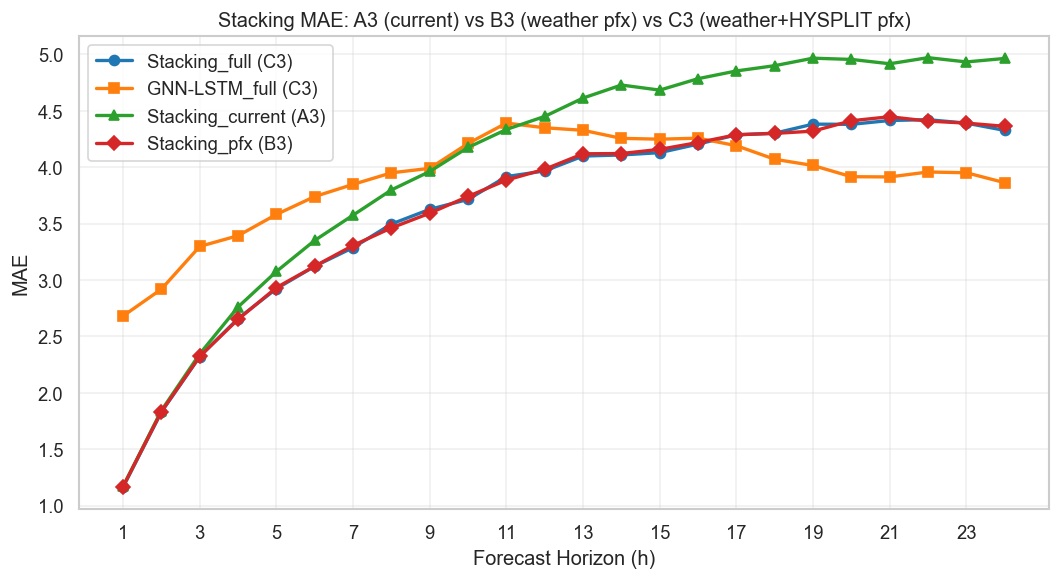

15:49:15 | src.evaluation | INFO | Saved figure: D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\outputs\figures\C3_vs_B3_vs_A3_r2.png


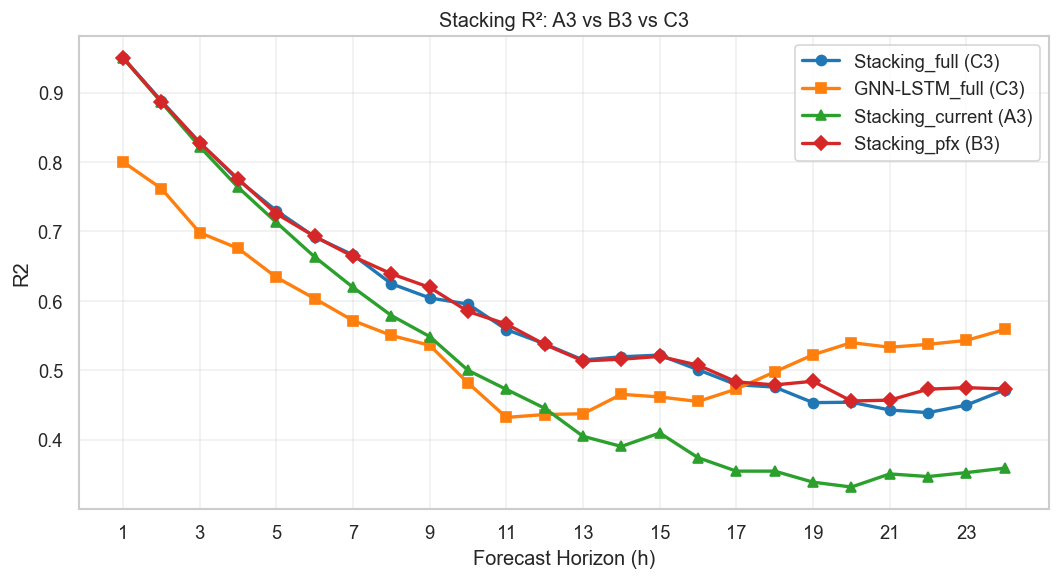

In [10]:
compare_stack = {
    'Stacking_full (C3)': results_stack_full,
    'GNN-LSTM_full (C3)': results_gnn_full,
}

for fname, model_label, series_label in [
    ('arch3_metrics.csv', 'Arch3_Stacking',  'Stacking_current (A3)'),
    ('B3_metrics.csv',    'B3_Stacking_pfx', 'Stacking_pfx (B3)'),
]:
    p = RESULTS_DIR / fname
    if p.exists():
        df_r = pd.read_csv(p)
        sub = df_r[df_r['Model'] == model_label]
        if not sub.empty:
            compare_stack[series_label] = {
                int(r['Horizon']): {'MAE': r['MAE'], 'RMSE': r['RMSE'],
                                    'R2': r['R2'], 'MBE': r['MBE'], 'IA': r['IA']}
                for _, r in sub.iterrows()
            }

fig = plot_horizon_metrics(compare_stack, metric='MAE',
                           save_path=FIGURES_DIR / 'C3_vs_B3_vs_A3_mae.png')
plt.title('Stacking MAE: A3 (current) vs B3 (weather pfx) vs C3 (weather+HYSPLIT pfx)')
plt.show()

fig = plot_horizon_metrics(compare_stack, metric='R2',
                           save_path=FIGURES_DIR / 'C3_vs_B3_vs_A3_r2.png')
plt.title('Stacking R²: A3 vs B3 vs C3')
plt.show()

## 9. Winter 2024 Time-Series Overlay

15:49:15 | src.feature_engineering | INFO | build_feature_matrix | horizon=24 | weather_mode=perfect_forecast_full
15:49:15 | src.feature_engineering | INFO | perfect_forecast_full: shifted 8 MET + 10 HYSPLIT_NUM + 2 HYSPLIT_CAT by -24 h
15:49:15 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
15:49:15 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
15:49:15 | src.feature_engineering | INFO |   X: (7766, 45) | y mean=12.60, y std=8.39
15:49:15 | src.feature_engineering | INFO | build_feature_matrix | horizon=24 | weather_mode=perfect_forecast_full
15:49:16 | src.feature_engineering | INFO | perfect_forecast_full: shifted 8 MET + 10 HYSPLIT_NUM + 2 HYSPLIT_CAT by -24 h
15:49:16 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
15:49:16 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
15:49:16 | src.feature_engineering | IN

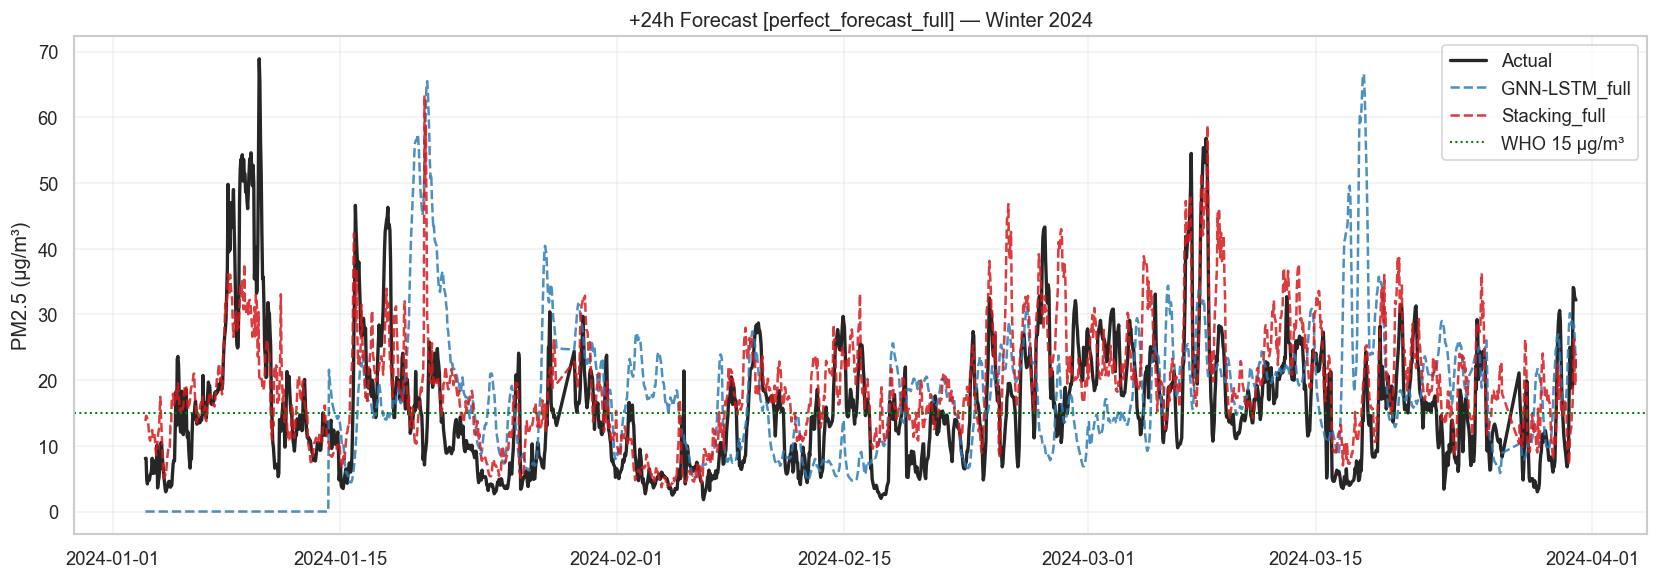

In [11]:
X_te_24, y_te_24 = build_feature_matrix(test_df, horizon=24, weather_mode=WEATHER_MODE)

predictions_winter = {}
n_tab = len(X_te_24)
gnn_pred_24 = np.zeros(n_tab)
n_gnn = len(gnn_preds)
if n_gnn >= n_tab:
    gnn_pred_24 = gnn_preds[-n_tab:, 23]
else:
    gnn_pred_24[-n_gnn:] = gnn_preds[:, 23]
predictions_winter['GNN-LSTM_full'] = gnn_pred_24

X_tr_24, y_tr_24 = build_feature_matrix(train_df, horizon=24, weather_mode=WEATHER_MODE)
stack_pred_24 = []
for name, factory in base_model_classes.items():
    m = factory()
    m.fit(X_tr_24.values, y_tr_24.values)
    stack_pred_24.append(m.predict(X_te_24.values))
stack_pred_24.append(gnn_pred_24)
meta_feats_24 = X_te_24[meta_feature_cols].values if meta_feature_cols else np.zeros((n_tab, 1))
predictions_winter['Stacking_full'] = predict_stacking(
    stack_models[24], np.column_stack(stack_pred_24), meta_feats_24
)

winter_mask = (y_te_24.index >= '2024-01-01') & (y_te_24.index <= '2024-03-31')
y_winter = y_te_24[winter_mask]

from src.config import WHO_24H_PM25
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_winter.index, y_winter.values, label='Actual', linewidth=2, color='black', alpha=0.85)
colors = ['#2c7bb6', '#d7191c']
for ci, (name, preds) in enumerate(predictions_winter.items()):
    pred_series = pd.Series(preds, index=y_te_24.index)[winter_mask]
    ax.plot(pred_series.index, pred_series.values, label=name,
            linewidth=1.5, linestyle='--', color=colors[ci % len(colors)], alpha=0.85)
ax.axhline(WHO_24H_PM25, color='green', linestyle=':', linewidth=1.2,
           label=f'WHO {WHO_24H_PM25} µg/m³')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_title('+24h Forecast [perfect_forecast_full] — Winter 2024')
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'C3_winter2024_overlay.png', bbox_inches='tight')
plt.show()

## 10. Smog Episode Analysis

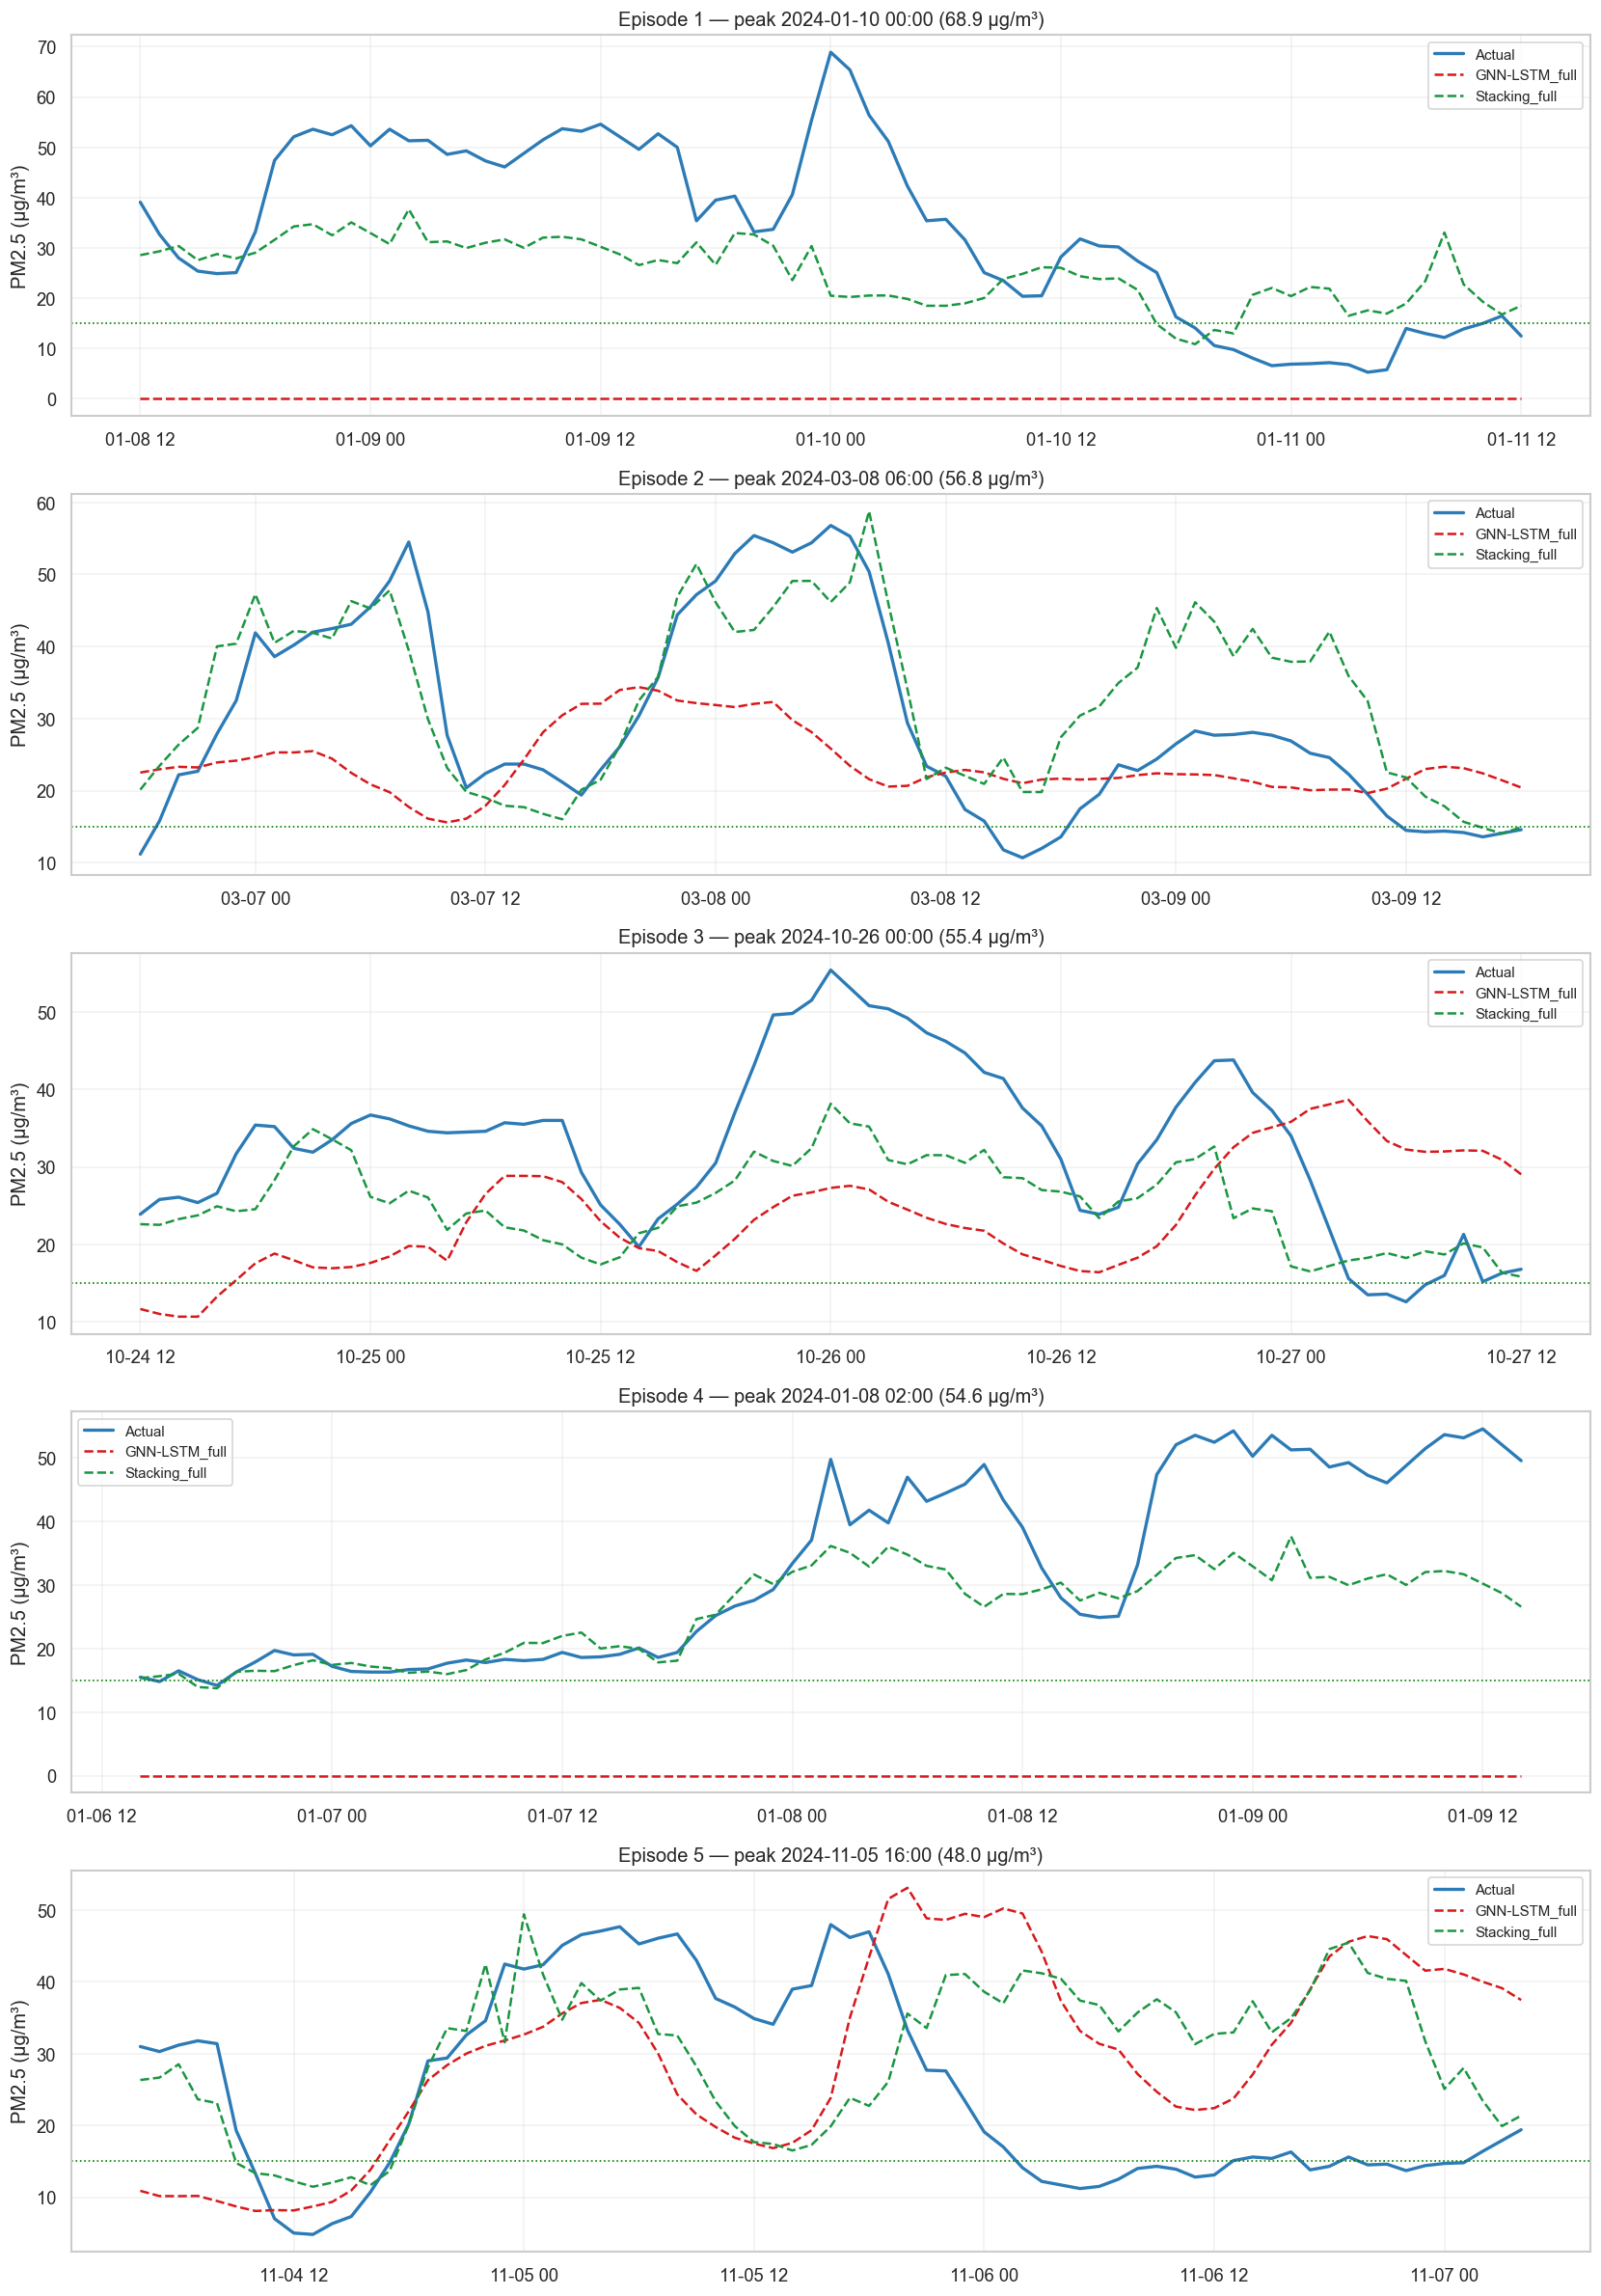

In [12]:
from src.evaluation import plot_smog_episodes

fig = plot_smog_episodes(
    y_te_24, predictions_winter, n_episodes=5,
    save_path=FIGURES_DIR / 'C3_smog_episodes.png'
)
plt.show()

## 11. Save Results — Full A + B + C Comparison Table

In [13]:
rows = []
for model_name, h_results in [('C3_GNN_LSTM_full', results_gnn_full),
                                ('C3_Stacking_full', results_stack_full)]:
    for h, metrics in h_results.items():
        rows.append({'Model': model_name, 'Horizon': h, **metrics})

pd.DataFrame(rows).to_csv(RESULTS_DIR / 'C3_metrics.csv', index=False)
print('Saved C3_metrics.csv')

# Merge all A + B + C results
all_dfs = []
for fname in ['arch1_metrics.csv', 'arch2_metrics.csv', 'arch3_metrics.csv',
              'B1_metrics.csv', 'B2_metrics.csv', 'B3_metrics.csv',
              'C1_metrics.csv', 'C2_metrics.csv', 'C3_metrics.csv']:
    p = RESULTS_DIR / fname
    if p.exists():
        all_dfs.append(pd.read_csv(p))

if all_dfs:
    final_df = pd.concat(all_dfs, ignore_index=True)
    final_df.to_csv(RESULTS_DIR / 'comparison_table_all.csv', index=False)
    print('Saved comparison_table_all.csv (A + B + C series)')

    key = final_df[final_df['Horizon'].isin([1, 6, 12, 24])]
    print('\nMAE pivot — key horizons (all series):')
    print(key.pivot_table(index='Model', columns='Horizon', values='MAE').round(3).to_string())

Saved C3_metrics.csv
Saved comparison_table_all.csv (A + B + C series)

MAE pivot — key horizons (all series):
Horizon              1      6      12     24
Model                                       
Arch1_HGB         1.135  3.146  4.068  4.499
Arch1_XGBoost     1.143  3.179  4.138  4.515
Arch2_CNN_LSTM    2.764  3.615  4.817  4.859
Arch3_GNN_LSTM    2.882  3.986  4.239  5.014
Arch3_Stacking    1.171  3.351  4.450  4.964
B1_HGB_pfx        1.133  3.060  3.873  4.116
B1_XGBoost_pfx    1.140  3.094  3.864  4.178
B2_CNN_LSTM_pfx   2.396  3.416  4.111  3.977
B3_GNN_LSTM_pfx   2.681  3.740  4.349  3.863
B3_Stacking_pfx   1.169  3.123  3.982  4.362
C1_HGB_full       1.132  3.073  3.900  4.334
C1_XGBoost_full   1.136  3.175  3.972  4.391
C2_CNN_LSTM_full  2.675  4.275  4.657  4.384
C3_GNN_LSTM_full  2.681  3.740  4.349  3.863
C3_Stacking_full  1.165  3.122  3.967  4.326
